In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("../data/german_credit_with_risk.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
y = df["Risk"].map({"good": 1, "bad": 0})
X = df.drop(columns=["Risk"])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

C:\Users\ahmds\AppData\Local\Temp\ipykernel_37288\609789413.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [7]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

In [8]:
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [ ]:
import os
import joblib

base_dir = os.path.dirname(os.getcwd())  # يطلع من notebooks/
models_dir = os.path.join(base_dir, "models")

os.makedirs(models_dir, exist_ok=True)
joblib.dump(clf, os.path.join(models_dir, "model.pkl"))
print(f"Saved in: {models_dir}")

Saved in: f:\Credit Risk Scoring System using Machine Learning\models


In [10]:
y_proba = clf.predict_proba(X_test)[:, 1]

threshold = 0.4  

y_pred = (y_proba > threshold).astype(int)

In [11]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.72      0.38      0.50        60
           1       0.78      0.94      0.85       140

    accuracy                           0.77       200
   macro avg       0.75      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200



In [12]:
XGBClassifier(scale_pos_weight=2.3)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

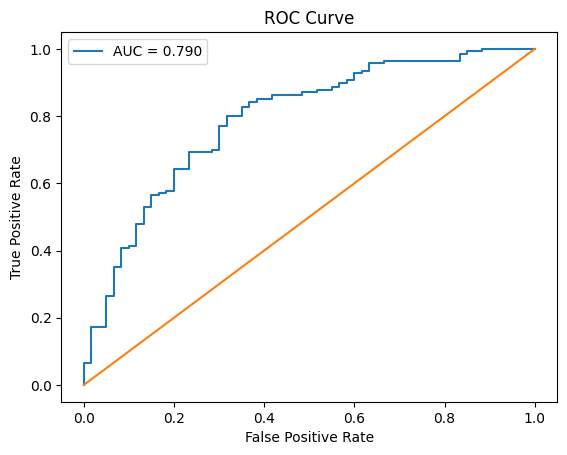

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

auc_score = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

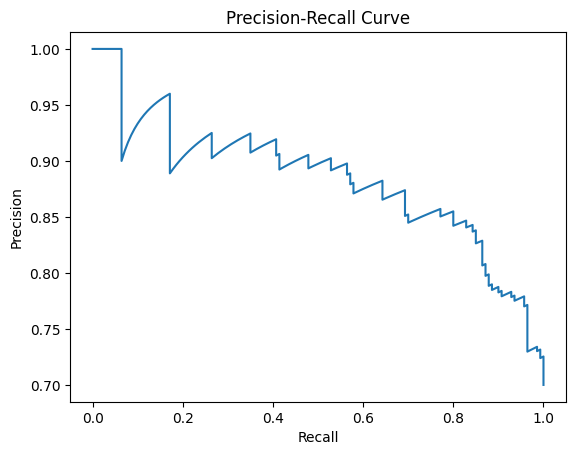

In [14]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [15]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0, 1, 100)

f1_scores = [
    f1_score(y_test, (y_proba >= t).astype(int))
    for t in thresholds
]

best_t = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_t)

Best threshold: 0.36363636363636365


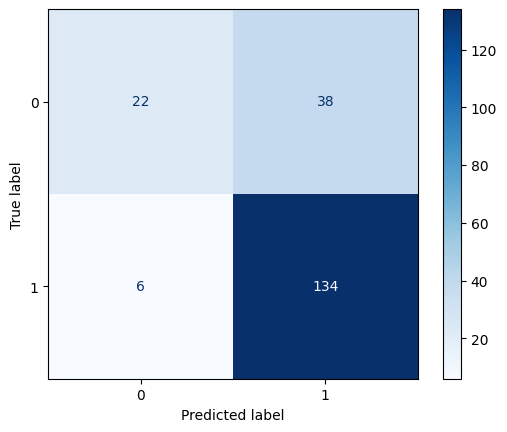

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_opt = (y_proba >= best_t).astype(int)

cm = confusion_matrix(y_test, y_pred_opt)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.show()

In [17]:
print(f"AUC Score: {auc_score:.3f}")

AUC Score: 0.790


In [18]:
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.32323232323232326


In [19]:
def credit_decision(prob):
    if prob >= optimal_threshold:
        return "Reject"
    else:
        return "Approve"

In [20]:
decisions = [credit_decision(p) for p in y_proba]

In [21]:
import pandas as pd

results = pd.DataFrame({
    "probability": y_proba,
    "decision": decisions,
    "actual": y_test.values
})

results.head()

,probability,decision,actual
0,0.914107,Reject,1
1,0.695978,Reject,1
2,0.526382,Reject,1
3,0.922840,Reject,1
4,0.751980,Reject,0


In [22]:
from sklearn.metrics import confusion_matrix

y_pred = (y_proba >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 16  44]
 [  5 135]]


In [23]:
tn, fp, fn, tp = cm.ravel()

loss_fn = fn * 1000
loss_fp = fp * 100 

total_cost = loss_fn + loss_fp

print("Total Business Cost:", total_cost)

Total Business Cost: 9400
